# Demo HyperFusion cho xơ vữa động mạch cảnh

Notebook này là một demo nhỏ có thể chạy được, dựa trên `README.md` và `readme(HVCH thuc hien).rtf`.

Mục tiêu: nạp file CSV lâm sàng, xem trước dữ liệu ảnh, và dựng một ví dụ gate lâm sàng nhỏ để bám đúng ý tưởng HyperFusion đa phương thức.

In [1]:
from pathlib import Path
import math
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

ROOT = Path.cwd()
CSV_PATH = ROOT / 'data' / 'clinical_carotid_dataset_v3' / 'clinical_carotid_dataset_v3' / 'carotid_clinical_dataset_300cases.csv'
IMG_DIR = ROOT / 'data' / 'clinical_carotid_dataset_v3' / 'clinical_carotid_dataset_v3' / 'CAROTID_IMAGES'

print('CSV tồn tại:', CSV_PATH.exists())
print('Thư mục ảnh tồn tại:', IMG_DIR.exists())

CSV tồn tại: True
Thư mục ảnh tồn tại: True


In [2]:
df = pd.read_csv(CSV_PATH)

print('Kích thước:', df.shape)
display(df.head(8))

summary_cols = [
    'Age', 'Lp(a)_mg_dL', 'ApoB_mg_dL', 'LDL_C_mg_dL', 'Triglyceride_mg_dL',
    'Total_Cholesterol_mg_dL', 'Non_HDL_mg_dL', 'IMT_mm', 'Plaque_present'
]
display(df[summary_cols].describe().T)

print('Tỷ lệ hiện diện mảng bám:', df['Plaque_present'].mean().round(3))
print('Tỷ lệ bệnh nhân có bộ ảnh > 1 file:', (df['Associated_Images'].fillna('').str.contains(',')).mean().round(3))

Kích thước: (300, 15)


,Patient_ID,Age,Sex,Lp(a)_mg_dL,ApoB_mg_dL,LDL_C_mg_dL,Triglyceride_mg_dL,Total_Cholesterol_mg_dL,Non_HDL_mg_dL,IMT_mm,Plaque_present,Plaque_echogenicity,Baseline_Risk_Score,Baseline_Risk_Category,Associated_Images
0,P001,59,Male,10.0,97.7,157.6,123.4,195.3,150.0,0.710,0,NaN,0.49,Low,P001_IMT.png
1,P002,53,Male,37.6,128.0,159.7,152.8,185.8,139.4,0.698,0,NaN,0.11,Low,P002_IMT.png
2,P003,61,Female,18.2,140.4,146.0,86.0,187.1,135.2,0.733,1,Low,0.14,Low,"P003_IMT.png,P003_CCA_L1.png,P003_CCA_L2.png,P..."
3,P004,70,Female,38.2,101.5,101.4,71.1,140.7,102.2,0.879,1,Intermediate,0.00,Low,"P004_IMT.png,P004_CCA_L1.png,P004_CCA_L2.png,P..."
4,P005,52,Female,17.2,99.2,170.8,70.0,186.8,156.9,0.637,0,NaN,0.08,Low,P005_IMT.png
5,P006,52,Male,9.2,127.3,101.3,70.0,147.6,101.7,0.665,0,NaN,1.02,Low,P006_IMT.png
6,P007,70,Male,10.2,129.2,137.6,226.4,159.5,105.5,0.722,0,NaN,1.17,Low,P007_IMT.png
7,P008,62,Female,27.9,98.6,111.1,70.0,153.3,102.1,0.705,0,NaN,0.73,Low,P008_IMT.png


,count,mean,std,min,25%,50%,75%,max
Age,300.0,54.396667,9.615309,30.00,48.0000,55.0000,61.000,80.000
Lp(a)_mg_dL,300.0,31.936667,20.584317,5.40,18.5250,27.4000,39.450,131.600
ApoB_mg_dL,300.0,108.889667,14.763115,62.60,98.7750,109.5000,118.475,144.600
LDL_C_mg_dL,300.0,131.170333,25.204607,70.00,113.0250,131.0500,147.050,194.500
Triglyceride_mg_dL,300.0,113.879333,44.589170,70.00,79.8000,102.2000,133.825,356.800
Total_Cholesterol_mg_dL,300.0,161.016000,29.358491,92.30,140.5750,160.0500,180.400,230.600
Non_HDL_mg_dL,300.0,115.934333,29.902876,45.20,95.2750,115.5000,135.550,194.400
IMT_mm,300.0,0.666853,0.091513,0.45,0.5995,0.6615,0.734,0.883
Plaque_present,300.0,0.316667,0.465953,0.00,0.0000,0.0000,1.000,1.000


Tỷ lệ hiện diện mảng bám: 0.317
Tỷ lệ bệnh nhân có bộ ảnh > 1 file: 0.317


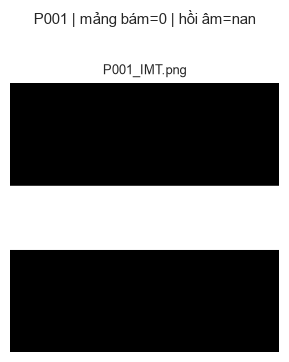

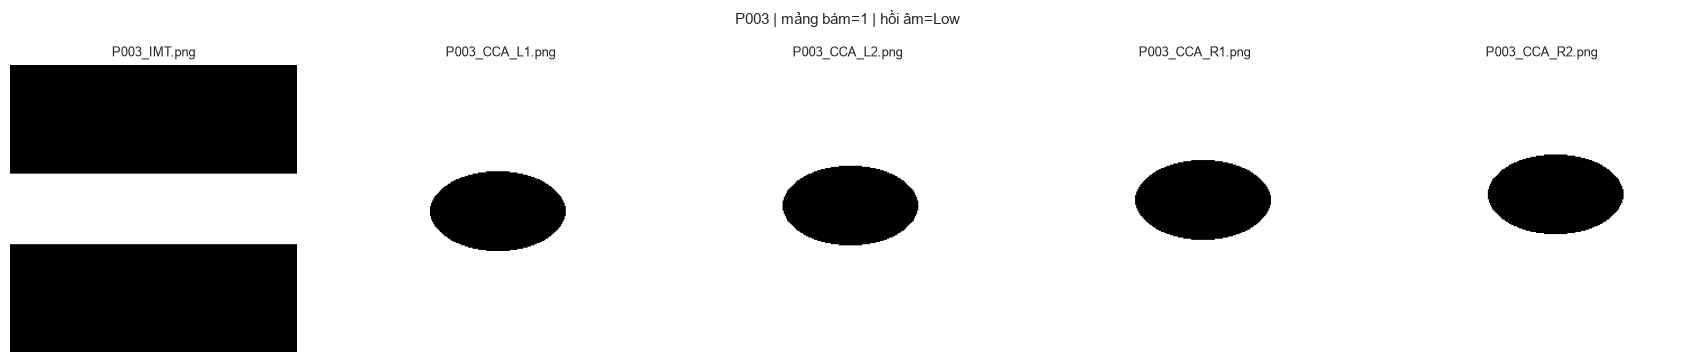

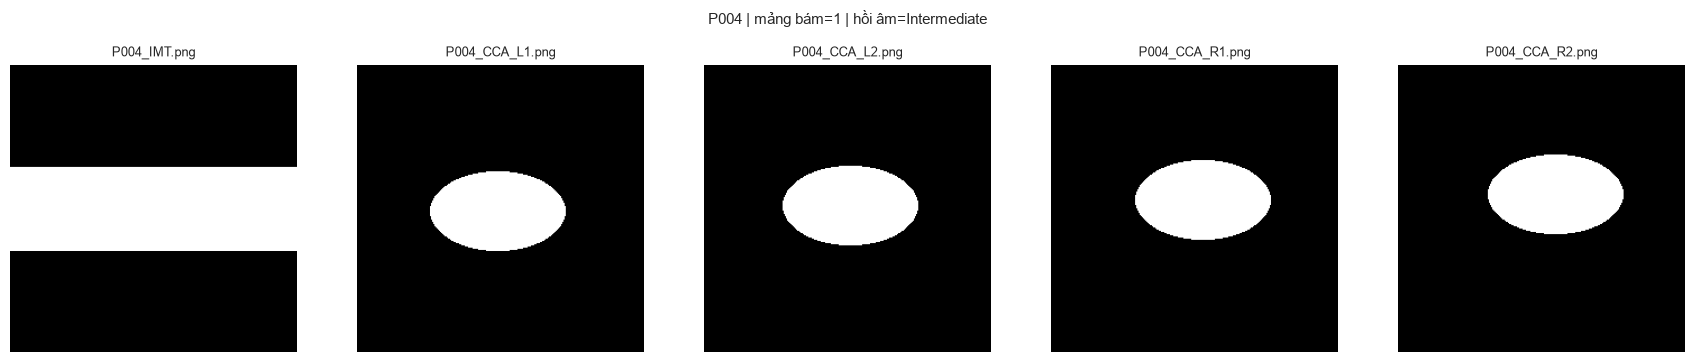

In [3]:
def parse_images(value):
    if pd.isna(value) or not str(value).strip():
        return []
    return [item.strip() for item in str(value).split(',') if item.strip()]

def image_path(patient_id, image_name):
    return IMG_DIR / image_name

def show_patient(patient_row, max_images=5):
    images = parse_images(patient_row['Associated_Images'])[:max_images]
    if not images:
        print(f"Không có ảnh cho {patient_row['Patient_ID']}")
        return

    fig, axes = plt.subplots(1, len(images), figsize=(3.5 * len(images), 3.5))
    if len(images) == 1:
        axes = [axes]

    for ax, img_name in zip(axes, images):
        img = Image.open(image_path(patient_row['Patient_ID'], img_name))
        ax.imshow(img, cmap='gray')
        ax.set_title(img_name, fontsize=9)
        ax.axis('off')

    fig.suptitle(
        f"{patient_row['Patient_ID']} | mảng bám={patient_row['Plaque_present']} | hồi âm={patient_row['Plaque_echogenicity']}",
        y=1.02,
        fontsize=11
    )
    plt.tight_layout()
    plt.show()

sample_cases = pd.concat([
    df[df['Plaque_present'] == 0].head(1),
    df[df['Plaque_present'] == 1].head(2)
]).drop_duplicates('Patient_ID')

for _, row in sample_cases.iterrows():
    show_patient(row)


Đã nạp dữ liệu xong!
Số mẫu train: 240
Số mẫu test: 60

Bắt đầu huấn luyện mô hình HyperFusion trên thiết bị: cpu
Epoch [1/50] | Loss: 0.6714 | Accuracy: 0.6042
Epoch [5/50] | Loss: 0.5295 | Accuracy: 0.7625
Epoch [10/50] | Loss: 0.4870 | Accuracy: 0.7917
Epoch [15/50] | Loss: 0.4573 | Accuracy: 0.7958
Epoch [20/50] | Loss: 0.4271 | Accuracy: 0.8167
Epoch [25/50] | Loss: 0.4080 | Accuracy: 0.8208
Epoch [30/50] | Loss: 0.3790 | Accuracy: 0.8208
Epoch [35/50] | Loss: 0.3508 | Accuracy: 0.8708
Epoch [40/50] | Loss: 0.3317 | Accuracy: 0.8750
Epoch [45/50] | Loss: 0.3017 | Accuracy: 0.8875
Epoch [50/50] | Loss: 0.2894 | Accuracy: 0.8833

KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST (20%)
Độ chính xác (Accuracy): 0.783
ROC-AUC Score: 0.66

Báo cáo phân loại chi tiết:
              precision    recall  f1-score   support

         0.0      0.769     0.976     0.860        41
         1.0      0.875     0.368     0.519        19

    accuracy                          0.783        60
   macro avg      0.822

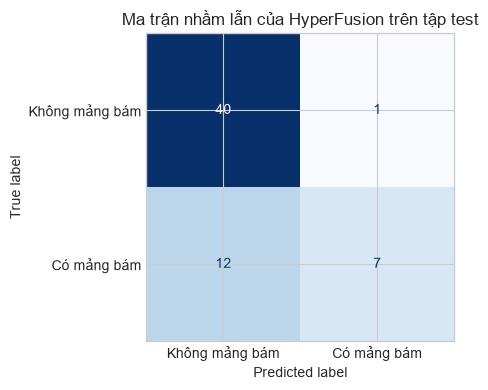

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ==========================================
# 1. ĐỊNH NGHĨA MÔ HÌNH HYPER-FUSION (FiLM)
# ==========================================
class HyperFusionModel(nn.Module):
    def __init__(self, num_clinical_features, num_cnn_filters=64):
        super().__init__()
        self.num_cnn_filters = num_cnn_filters

        # Nhánh lâm sàng
        self.clinical_mlp = nn.Sequential(
            nn.Linear(num_clinical_features, 32),
            nn.ReLU(),
            nn.Linear(32, num_cnn_filters * 2)
        )

        # Nhánh ảnh
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=num_cnn_filters, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(num_cnn_filters) # Thêm Batch Normalization để ổn định ảnh
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2)

        # FIX: Dùng Global Average Pooling thay vì Flatten toàn bộ ảnh
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # Lớp phân loại giờ chỉ nhận đúng 64 tham số thay vì 802,816
        self.classifier = nn.Linear(num_cnn_filters, 1)

    def forward(self, image, clinical_data):
        film_params = self.clinical_mlp(clinical_data)
        gamma = film_params[:, :self.num_cnn_filters].unsqueeze(-1).unsqueeze(-1)
        beta = film_params[:, self.num_cnn_filters:].unsqueeze(-1).unsqueeze(-1)

        img_features = self.conv1(image)
        img_features = self.bn1(img_features) # Chuẩn hóa trước khi Fusion
        
        modulated_features = (gamma * img_features) + beta
        out = self.relu(modulated_features)
        out = self.pool(out)
        
        # Gom đặc trưng không gian lại
        out = self.global_pool(out)
        out = torch.flatten(out, 1) # Phẳng hóa tensor thành [batch_size, 64]
        out = self.classifier(out)
        
        return out # FIX: Bỏ self.sigmoid(out) ở đây

# ==========================================
# 2. CHUẨN BỊ DỮ LIỆU ẢNH + LÂM SÀNG
# ==========================================
# KHAI BÁO BIẾN LÂM SÀNG (Đã fix lỗi NameError)
clinical_features = ['Age', 'Lp(a)_mg_dL', 'ApoB_mg_dL', 'LDL_C_mg_dL', 'Triglyceride_mg_dL', 'Non_HDL_mg_dL', 'IMT_mm']

def load_grayscale_image(image_name, image_size=224):
    image = Image.open(IMG_DIR / image_name).convert('L').resize((image_size, image_size))
    image_array = np.array(image, dtype=np.float32) / 255.0
    return torch.from_numpy(image_array).unsqueeze(0)

def extract_primary_image(value):
    images = parse_images(value)
    return images[0] if images else None

# Tách tập Train / Test
train_df, test_df = train_test_split(
    df.copy(),
    test_size=0.2,
    random_state=42,
    stratify=df['Plaque_present']
)

train_records = train_df[train_df['Associated_Images'].notna()].copy()
test_records = test_df[test_df['Associated_Images'].notna()].copy()

# Chuẩn hóa số liệu lâm sàng (Giúp mạng Nơ-ron không bị nổ gradient)
scaler = StandardScaler()
train_records[clinical_features] = scaler.fit_transform(train_records[clinical_features])
test_records[clinical_features] = scaler.transform(test_records[clinical_features])

# Nạp dữ liệu Train
X_train_images = []
X_train_clinical = []
y_train = []
for _, row in train_records.iterrows():
    image_name = extract_primary_image(row['Associated_Images'])
    if image_name is None:
        continue
    X_train_images.append(load_grayscale_image(image_name))
    X_train_clinical.append(row[clinical_features].to_numpy(dtype=np.float32))
    y_train.append(float(row['Plaque_present']))

# Nạp dữ liệu Test
X_test_images = []
X_test_clinical = []
y_test = []
for _, row in test_records.iterrows():
    image_name = extract_primary_image(row['Associated_Images'])
    if image_name is None:
        continue
    X_test_images.append(load_grayscale_image(image_name))
    X_test_clinical.append(row[clinical_features].to_numpy(dtype=np.float32))
    y_test.append(float(row['Plaque_present']))

# Chuyển đổi thành PyTorch Tensor
X_train_images = torch.stack(X_train_images)
X_train_clinical = torch.tensor(np.array(X_train_clinical), dtype=torch.float32)
y_train = torch.tensor(np.array(y_train), dtype=torch.float32)

X_test_images = torch.stack(X_test_images)
X_test_clinical = torch.tensor(np.array(X_test_clinical), dtype=torch.float32)
y_test = torch.tensor(np.array(y_test), dtype=torch.float32)

train_dataset = TensorDataset(X_train_images, X_train_clinical, y_train)
test_dataset = TensorDataset(X_test_images, X_test_clinical, y_test)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

print('\nĐã nạp dữ liệu xong!')
print('Số mẫu train:', len(train_dataset))
print('Số mẫu test:', len(test_dataset))

# ==========================================
# 3. HUẤN LUYỆN MÔ HÌNH
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = HyperFusionModel(num_clinical_features=len(clinical_features)).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 50

print('\nBắt đầu huấn luyện mô hình HyperFusion trên thiết bị:', device)
for epoch in range(epochs):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for batch_images, batch_clinical, batch_labels in train_loader:
        batch_images = batch_images.to(device)
        batch_clinical = batch_clinical.to(device)
        batch_labels = batch_labels.to(device).float().unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(batch_images, batch_clinical)
        loss = criterion(outputs, batch_labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        
        # Vì model xuất ra logits rác (chưa qua sigmoid), ta phải gọi torch.sigmoid() khi tính toán dự đoán
        predictions = (torch.sigmoid(outputs) >= 0.5).float()
        correct += (predictions == batch_labels).sum().item()
        total += batch_labels.size(0)

    epoch_acc = correct / total if total else 0.0
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch + 1}/{epochs}] | Loss: {total_loss / len(train_loader):.4f} | Accuracy: {epoch_acc:.4f}")

# ==========================================
# 4. ĐÁNH GIÁ TRÊN TẬP TEST
# ==========================================
model.eval()
all_predictions = []
all_probabilities = []
all_labels = []

with torch.no_grad():
    for batch_images, batch_clinical, batch_labels in test_loader:
        batch_images = batch_images.to(device)
        batch_clinical = batch_clinical.to(device)
        batch_labels = batch_labels.to(device).float().unsqueeze(1)

        outputs = model(batch_images, batch_clinical)
        all_probabilities.extend(outputs.squeeze(1).cpu().numpy().tolist())
        all_predictions.extend((outputs >= 0.5).float().squeeze(1).cpu().numpy().tolist())
        all_labels.extend(batch_labels.squeeze(1).cpu().numpy().tolist())

all_predictions = np.array(all_predictions)
all_probabilities = np.array(all_probabilities)
all_labels = np.array(all_labels)

test_accuracy = (all_predictions == all_labels).mean()
try:
    test_auc = roc_auc_score(all_labels, all_probabilities)
except ValueError:
    test_auc = float('nan')

print('\n' + '='*40)
print('KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST (20%)')
print('='*40)
print('Độ chính xác (Accuracy):', round(test_accuracy, 3))
print('ROC-AUC Score:', round(test_auc, 3) if not np.isnan(test_auc) else 'không xác định')
print('\nBáo cáo phân loại chi tiết:')
print(classification_report(all_labels, all_predictions, digits=3))

cm = confusion_matrix(all_labels, all_predictions)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['Không mảng bám', 'Có mảng bám']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Ma trận nhầm lẫn của HyperFusion trên tập test')
plt.tight_layout()
plt.show()

### C1 : Tách thành nhiều dòng


Đã nạp dữ liệu xong!
Số mẫu train: 544
Số mẫu test: 136

Bắt đầu huấn luyện mô hình HyperFusion trên thiết bị: cpu
Epoch [1/50] | Loss: 0.5904 | Accuracy: 0.6930
Epoch [5/50] | Loss: 0.4039 | Accuracy: 0.7941
Epoch [10/50] | Loss: 0.3254 | Accuracy: 0.8456
Epoch [15/50] | Loss: 0.2628 | Accuracy: 0.8842
Epoch [20/50] | Loss: 0.2345 | Accuracy: 0.9062
Epoch [25/50] | Loss: 0.1950 | Accuracy: 0.9191
Epoch [30/50] | Loss: 0.1804 | Accuracy: 0.9246
Epoch [35/50] | Loss: 0.1476 | Accuracy: 0.9540
Epoch [40/50] | Loss: 0.1532 | Accuracy: 0.9449
Epoch [45/50] | Loss: 0.1256 | Accuracy: 0.9596
Epoch [50/50] | Loss: 0.1237 | Accuracy: 0.9632

KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST (20%)
Độ chính xác (Accuracy): 0.816
ROC-AUC Score: 0.911

Báo cáo phân loại chi tiết:
              precision    recall  f1-score   support

         0.0      0.638     0.902     0.747        41
         1.0      0.949     0.779     0.855        95

    accuracy                          0.816       136
   macro avg      0.7

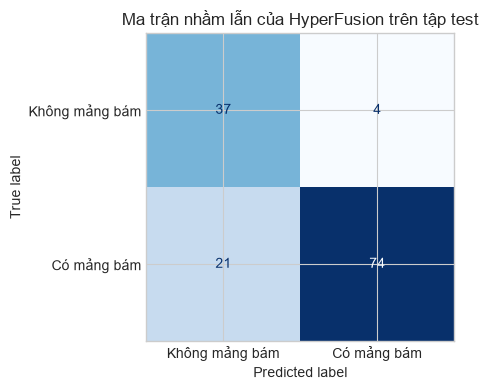

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ==========================================
# 1. ĐỊNH NGHĨA MÔ HÌNH HYPER-FUSION (FiLM)
# ==========================================
class HyperFusionModel(nn.Module):
    def __init__(self, num_clinical_features, num_cnn_filters=64):
        super().__init__()
        self.num_cnn_filters = num_cnn_filters

        # Nhánh lâm sàng
        self.clinical_mlp = nn.Sequential(
            nn.Linear(num_clinical_features, 32),
            nn.ReLU(),
            nn.Linear(32, num_cnn_filters * 2)
        )

        # Nhánh ảnh
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=num_cnn_filters, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(num_cnn_filters) # Thêm Batch Normalization để ổn định ảnh
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2)

        # FIX: Dùng Global Average Pooling thay vì Flatten toàn bộ ảnh
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # Lớp phân loại giờ chỉ nhận đúng 64 tham số thay vì 802,816
        self.classifier = nn.Linear(num_cnn_filters, 1)

    def forward(self, image, clinical_data):
        film_params = self.clinical_mlp(clinical_data)
        gamma = film_params[:, :self.num_cnn_filters].unsqueeze(-1).unsqueeze(-1)
        beta = film_params[:, self.num_cnn_filters:].unsqueeze(-1).unsqueeze(-1)

        img_features = self.conv1(image)
        img_features = self.bn1(img_features) # Chuẩn hóa trước khi Fusion
        
        modulated_features = (gamma * img_features) + beta
        out = self.relu(modulated_features)
        out = self.pool(out)
        
        # Gom đặc trưng không gian lại
        out = self.global_pool(out)
        out = torch.flatten(out, 1) # Phẳng hóa tensor thành [batch_size, 64]
        out = self.classifier(out)
        
        return out # FIX: Bỏ self.sigmoid(out) ở đây

# ==========================================
# 2. CHUẨN BỊ DỮ LIỆU ẢNH + LÂM SÀNG
# ==========================================
# KHAI BÁO BIẾN LÂM SÀNG (Đã fix lỗi NameError)
clinical_features = ['Age', 'Lp(a)_mg_dL', 'ApoB_mg_dL', 'LDL_C_mg_dL', 'Triglyceride_mg_dL', 'Non_HDL_mg_dL', 'IMT_mm']

def load_grayscale_image(image_name, image_size=224):
    image = Image.open(IMG_DIR / image_name).convert('L').resize((image_size, image_size))
    image_array = np.array(image, dtype=np.float32) / 255.0
    return torch.from_numpy(image_array).unsqueeze(0)

def extract_primary_image(value):
    images = parse_images(value)
    return images[0] if images else None

# Tách tập Train / Test
train_df, test_df = train_test_split(
    df.copy(),
    test_size=0.2,
    random_state=42,
    stratify=df['Plaque_present']
)

train_records = train_df[train_df['Associated_Images'].notna()].copy()
test_records = test_df[test_df['Associated_Images'].notna()].copy()

# Chuẩn hóa số liệu lâm sàng (Giúp mạng Nơ-ron không bị nổ gradient)
scaler = StandardScaler()
train_records[clinical_features] = scaler.fit_transform(train_records[clinical_features])
test_records[clinical_features] = scaler.transform(test_records[clinical_features])

# Nạp dữ liệu Train (Tách dòng)
X_train_images = []
X_train_clinical = []
y_train = []
for _, row in train_records.iterrows():
    images = parse_images(row['Associated_Images'])
    if not images:
        continue
    # Duyệt qua từng ảnh của bệnh nhân này để tạo thành các dòng riêng biệt
    for image_name in images:
        X_train_images.append(load_grayscale_image(image_name))
        X_train_clinical.append(row[clinical_features].to_numpy(dtype=np.float32))
        y_train.append(float(row['Plaque_present']))

# Nạp dữ liệu Test (Tách dòng)
X_test_images = []
X_test_clinical = []
y_test = []
for _, row in test_records.iterrows():
    images = parse_images(row['Associated_Images'])
    if not images:
        continue
    # Duyệt qua từng ảnh của bệnh nhân này để tạo thành các dòng riêng biệt
    for image_name in images:
        X_test_images.append(load_grayscale_image(image_name))
        X_test_clinical.append(row[clinical_features].to_numpy(dtype=np.float32))
        y_test.append(float(row['Plaque_present']))

# Chuyển đổi thành PyTorch Tensor
X_train_images = torch.stack(X_train_images)
X_train_clinical = torch.tensor(np.array(X_train_clinical), dtype=torch.float32)
y_train = torch.tensor(np.array(y_train), dtype=torch.float32)

X_test_images = torch.stack(X_test_images)
X_test_clinical = torch.tensor(np.array(X_test_clinical), dtype=torch.float32)
y_test = torch.tensor(np.array(y_test), dtype=torch.float32)

train_dataset = TensorDataset(X_train_images, X_train_clinical, y_train)
test_dataset = TensorDataset(X_test_images, X_test_clinical, y_test)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

print('\nĐã nạp dữ liệu xong!')
print('Số mẫu train:', len(train_dataset))
print('Số mẫu test:', len(test_dataset))

# ==========================================
# 3. HUẤN LUYỆN MÔ HÌNH
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = HyperFusionModel(num_clinical_features=len(clinical_features)).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 50

print('\nBắt đầu huấn luyện mô hình HyperFusion trên thiết bị:', device)
for epoch in range(epochs):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for batch_images, batch_clinical, batch_labels in train_loader:
        batch_images = batch_images.to(device)
        batch_clinical = batch_clinical.to(device)
        batch_labels = batch_labels.to(device).float().unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(batch_images, batch_clinical)
        loss = criterion(outputs, batch_labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        
        # Vì model xuất ra logits rác (chưa qua sigmoid), ta phải gọi torch.sigmoid() khi tính toán dự đoán
        predictions = (torch.sigmoid(outputs) >= 0.5).float()
        correct += (predictions == batch_labels).sum().item()
        total += batch_labels.size(0)

    epoch_acc = correct / total if total else 0.0
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch + 1}/{epochs}] | Loss: {total_loss / len(train_loader):.4f} | Accuracy: {epoch_acc:.4f}")

# ==========================================
# 4. ĐÁNH GIÁ TRÊN TẬP TEST
# ==========================================
model.eval()
all_predictions = []
all_probabilities = []
all_labels = []

with torch.no_grad():
    for batch_images, batch_clinical, batch_labels in test_loader:
        batch_images = batch_images.to(device)
        batch_clinical = batch_clinical.to(device)
        batch_labels = batch_labels.to(device).float().unsqueeze(1)

        outputs = model(batch_images, batch_clinical)
        all_probabilities.extend(outputs.squeeze(1).cpu().numpy().tolist())
        all_predictions.extend((outputs >= 0.5).float().squeeze(1).cpu().numpy().tolist())
        all_labels.extend(batch_labels.squeeze(1).cpu().numpy().tolist())

all_predictions = np.array(all_predictions)
all_probabilities = np.array(all_probabilities)
all_labels = np.array(all_labels)

test_accuracy = (all_predictions == all_labels).mean()
try:
    test_auc = roc_auc_score(all_labels, all_probabilities)
except ValueError:
    test_auc = float('nan')

print('\n' + '='*40)
print('KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST (20%)')
print('='*40)
print('Độ chính xác (Accuracy):', round(test_accuracy, 3))
print('ROC-AUC Score:', round(test_auc, 3) if not np.isnan(test_auc) else 'không xác định')
print('\nBáo cáo phân loại chi tiết:')
print(classification_report(all_labels, all_predictions, digits=3))

cm = confusion_matrix(all_labels, all_predictions)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['Không mảng bám', 'Có mảng bám']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Ma trận nhầm lẫn của HyperFusion trên tập test')
plt.tight_layout()
plt.show()

### C2 : Trích xuất đặc trưng gộp

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ==========================================
# 1. ĐỊNH NGHĨA MÔ HÌNH HYPER-FUSION (FiLM)
# ==========================================
class HyperFusionModel(nn.Module):
    def __init__(self, num_clinical_features, num_cnn_filters=64, num_input_images=5):
        super().__init__()
        self.num_cnn_filters = num_cnn_filters

        self.clinical_mlp = nn.Sequential(
            nn.Linear(num_clinical_features, 32),
            nn.ReLU(),
            nn.Linear(32, num_cnn_filters * 2)
        )

        # Sửa in_channels từ 1 -> num_input_images (5)
        self.conv1 = nn.Conv2d(in_channels=num_input_images, out_channels=num_cnn_filters,
                                kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(num_cnn_filters)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2)
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(num_cnn_filters, 1)

    def forward(self, image, clinical_data):
        film_params = self.clinical_mlp(clinical_data)
        gamma = film_params[:, :self.num_cnn_filters].unsqueeze(-1).unsqueeze(-1)
        beta = film_params[:, self.num_cnn_filters:].unsqueeze(-1).unsqueeze(-1)

        img_features = self.conv1(image)
        img_features = self.bn1(img_features) # Chuẩn hóa trước khi Fusion
        
        modulated_features = (gamma * img_features) + beta
        out = self.relu(modulated_features)
        out = self.pool(out)
        
        # Gom đặc trưng không gian lại
        out = self.global_pool(out)
        out = torch.flatten(out, 1) # Phẳng hóa tensor thành [batch_size, 64]
        out = self.classifier(out)
        
        return out # FIX: Bỏ self.sigmoid(out) ở đây

# ==========================================
# 2. CHUẨN BỊ DỮ LIỆU ẢNH + LÂM SÀNG
# ==========================================
# KHAI BÁO BIẾN LÂM SÀNG (Đã fix lỗi NameError)

def load_multiple_images(associated_images_str, max_images=5):
    images = parse_images(associated_images_str)
    loaded_imgs = []
    
    for img_name in images[:max_images]:
        loaded_imgs.append(load_grayscale_image(img_name))  # mỗi ảnh: [1, 224, 224]
        
    while len(loaded_imgs) < max_images:
        if loaded_imgs:
            loaded_imgs.append(loaded_imgs[-1].clone())
        else:
            loaded_imgs.append(torch.zeros(1, 224, 224))
            
    stacked = torch.stack(loaded_imgs)      # [5, 1, 224, 224]
    return stacked.squeeze(1)               # [5, 224, 224]  ← 5 "kênh"

clinical_features = ['Age', 'Lp(a)_mg_dL', 'ApoB_mg_dL', 'LDL_C_mg_dL', 'Triglyceride_mg_dL', 'Non_HDL_mg_dL', 'IMT_mm']

def load_grayscale_image(image_name, image_size=224):
    image = Image.open(IMG_DIR / image_name).convert('L').resize((image_size, image_size))
    image_array = np.array(image, dtype=np.float32) / 255.0
    return torch.from_numpy(image_array).unsqueeze(0)

def extract_primary_image(value):
    images = parse_images(value)
    return images[0] if images else None

# Tách tập Train / Test
train_df, test_df = train_test_split(
    df.copy(),
    test_size=0.2,
    random_state=42,
    stratify=df['Plaque_present']
)

train_records = train_df[train_df['Associated_Images'].notna()].copy()
test_records = test_df[test_df['Associated_Images'].notna()].copy()

# Chuẩn hóa số liệu lâm sàng (Giúp mạng Nơ-ron không bị nổ gradient)
scaler = StandardScaler()
train_records[clinical_features] = scaler.fit_transform(train_records[clinical_features])
test_records[clinical_features] = scaler.transform(test_records[clinical_features])

# Nạp dữ liệu Train
X_train_images = []
X_train_clinical = []
y_train = []
for _, row in train_records.iterrows():
    X_train_images.append(load_multiple_images(row['Associated_Images']))
    X_train_clinical.append(row[clinical_features].to_numpy(dtype=np.float32))
    y_train.append(float(row['Plaque_present']))

# Nạp dữ liệu Test (Cách 2)
X_test_images = []
X_test_clinical = []
y_test = []
for _, row in test_records.iterrows():
    X_test_images.append(load_multiple_images(row['Associated_Images']))
    X_test_clinical.append(row[clinical_features].to_numpy(dtype=np.float32))
    y_test.append(float(row['Plaque_present']))

# Chuyển đổi thành PyTorch Tensor
X_train_images = torch.stack(X_train_images)
X_train_clinical = torch.tensor(np.array(X_train_clinical), dtype=torch.float32)
y_train = torch.tensor(np.array(y_train), dtype=torch.float32)

X_test_images = torch.stack(X_test_images)
X_test_clinical = torch.tensor(np.array(X_test_clinical), dtype=torch.float32)
y_test = torch.tensor(np.array(y_test), dtype=torch.float32)

train_dataset = TensorDataset(X_train_images, X_train_clinical, y_train)
test_dataset = TensorDataset(X_test_images, X_test_clinical, y_test)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

print('\nĐã nạp dữ liệu xong!')
print('Số mẫu train:', len(train_dataset))
print('Số mẫu test:', len(test_dataset))

# ==========================================
# 3. HUẤN LUYỆN MÔ HÌNH
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = HyperFusionModel(num_clinical_features=len(clinical_features)).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 50

print('\nBắt đầu huấn luyện mô hình HyperFusion trên thiết bị:', device)
for epoch in range(epochs):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for batch_images, batch_clinical, batch_labels in train_loader:
        batch_images = batch_images.to(device)
        batch_clinical = batch_clinical.to(device)
        batch_labels = batch_labels.to(device).float().unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(batch_images, batch_clinical)
        loss = criterion(outputs, batch_labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        
        # Vì model xuất ra logits rác (chưa qua sigmoid), ta phải gọi torch.sigmoid() khi tính toán dự đoán
        predictions = (torch.sigmoid(outputs) >= 0.5).float()
        correct += (predictions == batch_labels).sum().item()
        total += batch_labels.size(0)

    epoch_acc = correct / total if total else 0.0
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch + 1}/{epochs}] | Loss: {total_loss / len(train_loader):.4f} | Accuracy: {epoch_acc:.4f}")

# ==========================================
# 4. ĐÁNH GIÁ TRÊN TẬP TEST
# ==========================================
model.eval()
all_predictions = []
all_probabilities = []
all_labels = []

with torch.no_grad():
    for batch_images, batch_clinical, batch_labels in test_loader:
        batch_images = batch_images.to(device)
        batch_clinical = batch_clinical.to(device)
        batch_labels = batch_labels.to(device).float().unsqueeze(1)

        outputs = model(batch_images, batch_clinical)
        all_probabilities.extend(outputs.squeeze(1).cpu().numpy().tolist())
        all_predictions.extend((outputs >= 0.5).float().squeeze(1).cpu().numpy().tolist())
        all_labels.extend(batch_labels.squeeze(1).cpu().numpy().tolist())

all_predictions = np.array(all_predictions)
all_probabilities = np.array(all_probabilities)
all_labels = np.array(all_labels)

test_accuracy = (all_predictions == all_labels).mean()
try:
    test_auc = roc_auc_score(all_labels, all_probabilities)
except ValueError:
    test_auc = float('nan')

print('\n' + '='*40)
print('KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST (20%)')
print('='*40)
print('Độ chính xác (Accuracy):', round(test_accuracy, 3))
print('ROC-AUC Score:', round(test_auc, 3) if not np.isnan(test_auc) else 'không xác định')
print('\nBáo cáo phân loại chi tiết:')
print(classification_report(all_labels, all_predictions, digits=3))

cm = confusion_matrix(all_labels, all_predictions)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['Không mảng bám', 'Có mảng bám']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Ma trận nhầm lẫn của HyperFusion trên tập test')
plt.tight_layout()
plt.show()


Đã nạp dữ liệu xong!
Số mẫu train: 240
Số mẫu test: 60

Bắt đầu huấn luyện mô hình HyperFusion trên thiết bị: cpu


RuntimeError: Expected 3D (unbatched) or 4D (batched) input to conv2d, but got input of size: [8, 5, 1, 224, 224]